# 03a — Baselines y refinamiento

Este notebook ejecuta y compara los baselines de esta etapa usando exclusivamente:

- `partition == development`;
- folds persistidos en `splits.parquet`;
- una implementación común de métricas y cross-validation;
- pipelines que ajustan todo preprocesamiento dentro de outer train.

Los test finales no se cargan ni se utilizan.

La presentación prioriza gráficos y diagnósticos por clase. Los resultados completos por fold se conservan en:

```text
reports/cv_results.csv
reports/feature_selection.csv
```

Las matrices de confusión se construyen con predicciones *out-of-fold* concatenadas y se normalizan por clase verdadera.

## 1. Configuración y carga de artefactos

In [1]:
import sys
from functools import partial
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.evaluation.oof_predictions import (
    collect_oof_predictions,
    combine_configurations,
    load_or_collect_oof,
    select_best_baselines,
    select_controlled_refinement_tracks,
)
from src.evaluation.reporting import (
    save_cv_results,
    save_feature_selection,
    summarize_cv_results,
    upsert_cv_results,
    upsert_feature_selection,
)
from src.experiments.baselines import run_baseline_grid
from src.experiments.representation_refinement import (
    run_feature_importance_grid,
    run_pca_grid,
    run_rfecv_grid,
)
from src.feature_selection.importance import summarize_feature_importance
from src.features.feature_store import load_representation
from src.utils.config import get_config, resolve_path
from src.utils.io import load_metadata, load_splits
from src.utils.refinement_visualization import (
    plot_best_baseline_confusions,
    plot_controlled_refinement_confusions,
    plot_feature_importance_summary,
    plot_pca_diagnostics,
    plot_ranked_configurations,
    plot_rfecv_diagnostics,
)
from src.utils.reproducibility import set_global_seed

cfg = get_config()
set_global_seed(cfg.seed)

metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)
representations = {
    name: load_representation(name, cfg.paths.features_dir)
    for name in ("egemaps", "wav2vec")
}

print(f"Metadata: {metadata.shape}")
print(f"Splits: {splits.shape}")
for name, frame in representations.items():
    print(f"{name}: {frame.shape}")


2026-07-04 15:20:46 | INFO     | src.features.feature_store | Cargado 'egemaps': 1440 muestras, 88 features.
2026-07-04 15:20:46 | INFO     | src.features.feature_store | Cargado 'wav2vec': 1440 muestras, 768 features.
Metadata: (1440, 23)
Splits: (1440, 3)
egemaps: (1440, 89)
wav2vec: (1440, 769)


## 2. Configuración de ejecución

Los bloques pueden ejecutarse de forma independiente. Para analizar resultados ya calculados, mantener los flags en `False`.

La matriz completa de baselines contiene:

```text
2 representaciones × 1 protocolo (speaker_independent) × 3 targets × 3 modelos × 5 folds
= 18 configuraciones × 5 folds = 90 resultados por fold
```

> Nota: la versión original de esta celda mencionaba 2 protocolos, pero `PROTOCOLS` solo incluye `speaker_independent` — el proyecto no corre un protocolo speaker-dependent (ver `01_data_audio_splits.ipynb`). El conteo real ejecutado (18 configuraciones, 90 filas) confirma que la matriz es 2×1×3×3, no 2×2×3×3.

In [ ]:
RUN_BASELINES = True
RUN_FEATURE_IMPORTANCE = True
RUN_RFECV = True
RUN_PCA = True
RUN_CONFUSION_MATRICES = True

REPRESENTATIONS = ["egemaps", "wav2vec"]
PROTOCOLS = ["speaker_independent"]
TARGETS = [
    "emotion_original",
    "emotion_quadrant",
    "emotion_original_eval_quadrant",
]
MODELS = [
    "random_forest",
    "logistic_regression",
    "mlp",
]

PRIMARY_METRIC = getattr(
    getattr(cfg, "evaluation", None),
    "primary_metric",
    "balanced_accuracy",
)

cv_results_path = resolve_path("reports/cv_results.csv")
feature_selection_path = resolve_path("reports/feature_selection.csv")
oof_cache_path = resolve_path("reports/oof_predictions_selected.csv")

if RUN_BASELINES:
    baseline_output = run_baseline_grid(
        representations=representations,
        metadata=metadata,
        splits=splits,
        model_configs=cfg.models,
        seed=cfg.seed,
        representation_names=REPRESENTATIONS,
        protocols=PROTOCOLS,
        targets=TARGETS,
        models=MODELS,
        n_folds=cfg.splits.cv_folds,
    )
    cv_results = baseline_output["fold_results"]
    save_cv_results(cv_results, cv_results_path)
    print(f"Resultados baseline guardados en {cv_results_path}")
elif cv_results_path.exists():
    cv_results = pd.read_csv(cv_results_path)
    print(f"Resultados cargados desde {cv_results_path}")
else:
    cv_results = pd.DataFrame()
    print("No existe reports/cv_results.csv. Activar RUN_BASELINES para generarlo.")

feature_selection = (
    pd.read_csv(feature_selection_path)
    if feature_selection_path.exists()
    else pd.DataFrame()
)


2026-07-04 15:20:46 | INFO     | src.experiments.baselines | Baseline 1/18: egemaps | speaker_independent | emotion_original | random_forest
2026-07-04 15:20:46 | INFO     | src.experiments.cross_validation | === CV: egemaps_random_forest_emotion_original_speaker_independent_none ===
2026-07-04 15:20:47 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.4899 | BalAcc=0.4922 | UAR=0.4922 | Acc=0.4875
2026-07-04 15:20:47 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.4104 | BalAcc=0.4023 | UAR=0.4023 | Acc=0.4125
2026-07-04 15:20:48 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.4900 | BalAcc=0.4961 | UAR=0.4961 | Acc=0.4958
2026-07-04 15:20:49 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.5169 | BalAcc=0.5273 | UAR=0.5273 | Acc=0.5292
2026-07-04 15:20:49 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.4430 | BalAcc=0.4414 | UAR=0.4414 | Acc=0.4542
2026-07-04 15:20:49 | INFO     | src.experiments.cross_validation | === egemaps_random_for

## 3. Panorama visual de resultados

18 configuraciones consolidadas · 90 resultados por fold


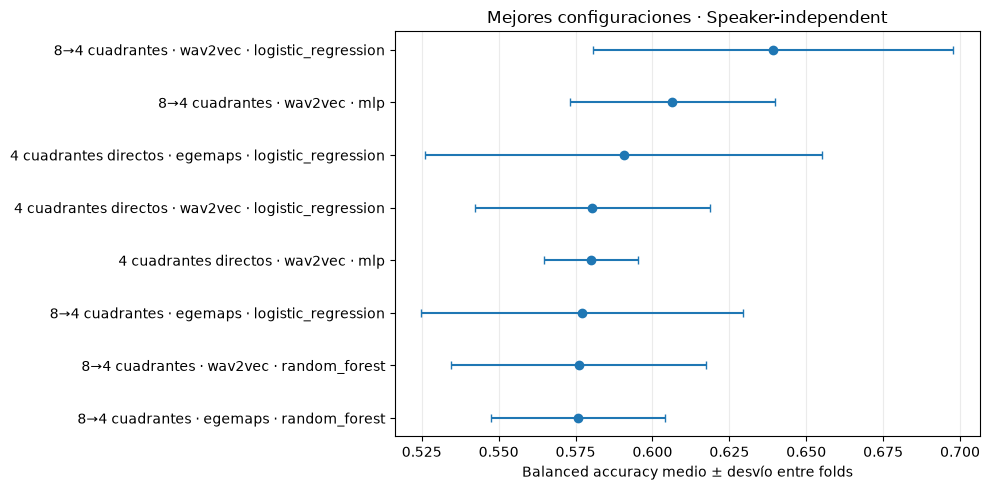

In [3]:
if cv_results.empty:
    summary = pd.DataFrame()
    print("Sin resultados consolidados.")
else:
    summary = summarize_cv_results(cv_results)
    print(
        f"{len(summary)} configuraciones consolidadas · "
        f"{len(cv_results)} resultados por fold"
    )
    figure = plot_ranked_configurations(
        summary,
        protocol=PROTOCOLS[0],
        metric=PRIMARY_METRIC,
        top_n=8,
    )
    if figure is not None:
        plt.show()


### Lectura

- El punto representa el balanced_accuracy medio.
- La barra horizontal representa el desvío entre folds.
- Configuraciones cercanas deben interpretarse junto con su estabilidad y complejidad.

Para `emotion_original` y para la evaluación colapsada de ocho emociones a cuadrantes, wav2vec + Logistic Regression obtiene el mejor rendimiento. En la clasificación directa de cuadrantes, eGeMAPS + Logistic Regression alcanza una balanced accuracy ligeramente superior a wav2vec. Esta diferencia sugiere que las features acústicas expertas pueden resultar competitivas cuando el objetivo se reduce a dimensiones emocionales amplias, particularmente arousal.

## 4. Feature importance sobre eGeMAPSv02

In [4]:
if RUN_FEATURE_IMPORTANCE:
    importance_output = run_feature_importance_grid(
        egemaps=representations["egemaps"],
        metadata=metadata,
        splits=splits,
        model_configs=cfg.models,
        seed=cfg.seed,
        protocols=PROTOCOLS,
        targets=TARGETS,
        top_k=cfg.refinements.feature_importance.top_k,
        permutation_repeats=cfg.refinements.feature_importance.permutation_repeats,
        n_folds=cfg.splits.cv_folds,
    )
    feature_selection = upsert_feature_selection(
        feature_selection,
        importance_output["feature_results"],
    )
    save_feature_selection(feature_selection, feature_selection_path)
    print(f"Importancias guardadas en {feature_selection_path}")

importance_rows = (
    feature_selection.query("method != 'rfecv'")
    if not feature_selection.empty
    else pd.DataFrame()
)
importance_summary = summarize_feature_importance(importance_rows)

2026-07-04 15:22:01 | INFO     | src.feature_selection.importance | Feature importance: emotion_original | fold=0
2026-07-04 15:22:56 | INFO     | src.feature_selection.importance | Feature importance: emotion_original | fold=1
2026-07-04 15:23:49 | INFO     | src.feature_selection.importance | Feature importance: emotion_original | fold=2
2026-07-04 15:24:43 | INFO     | src.feature_selection.importance | Feature importance: emotion_original | fold=3
2026-07-04 15:25:37 | INFO     | src.feature_selection.importance | Feature importance: emotion_original | fold=4
2026-07-04 15:26:31 | INFO     | src.feature_selection.importance | Feature importance: emotion_quadrant | fold=0
2026-07-04 15:27:25 | INFO     | src.feature_selection.importance | Feature importance: emotion_quadrant | fold=1
2026-07-04 15:28:18 | INFO     | src.feature_selection.importance | Feature importance: emotion_quadrant | fold=2
2026-07-04 15:29:13 | INFO     | src.feature_selection.importance | Feature importance: 

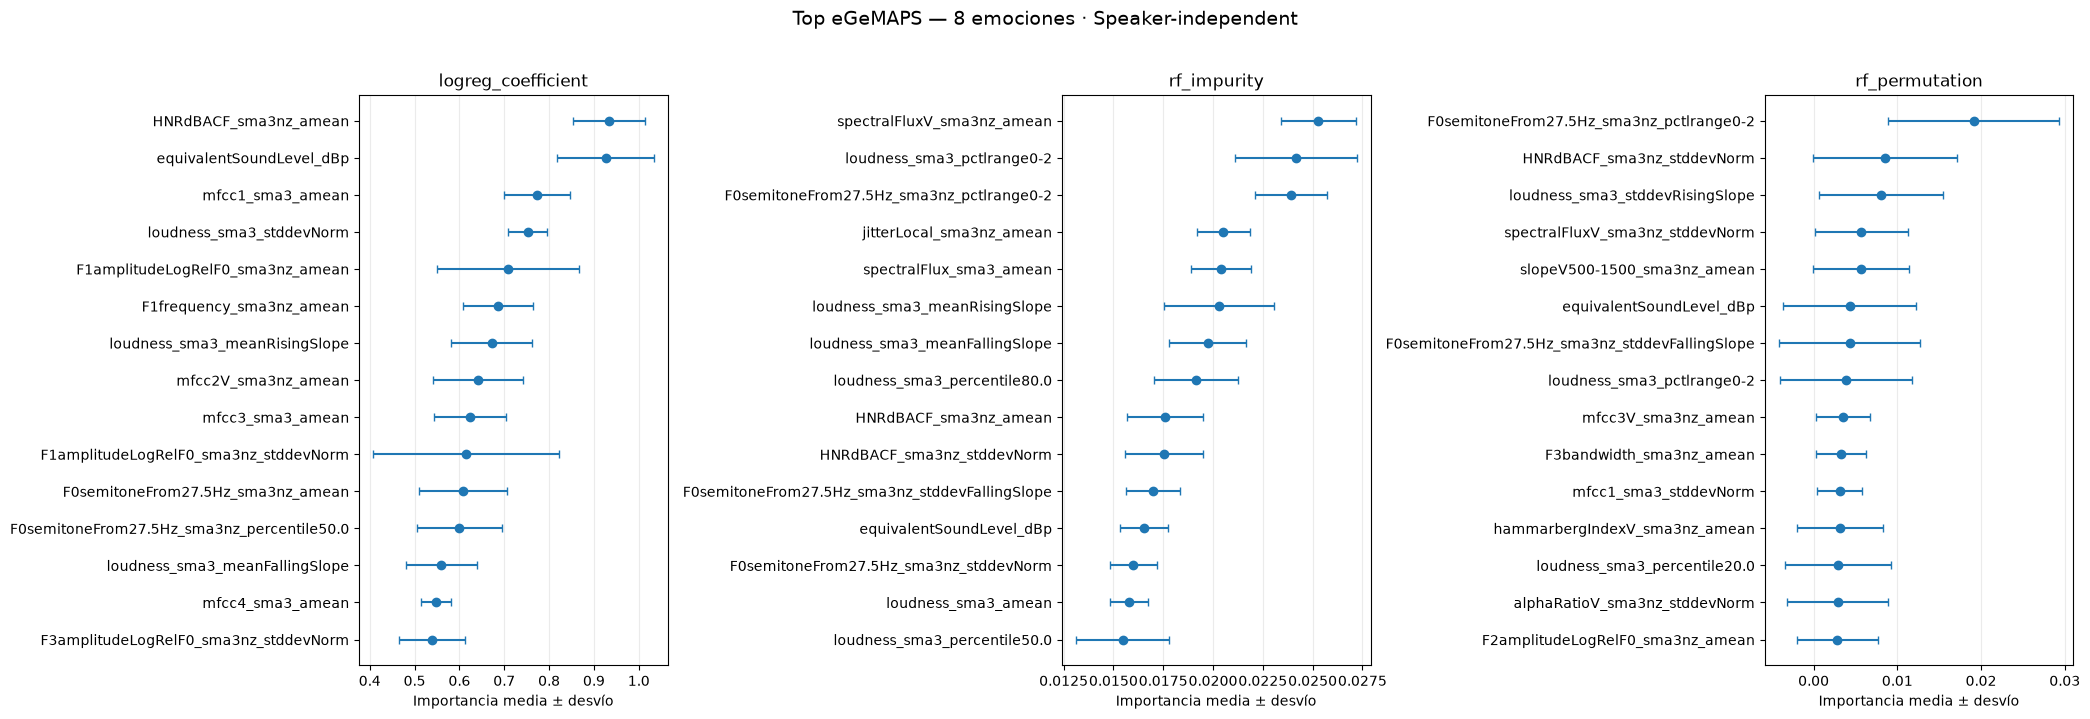

In [5]:
IMPORTANCE_PROTOCOL = PROTOCOLS[0]
IMPORTANCE_TARGET = "emotion_original"
IMPORTANCE_TOP_K = 15

figure = plot_feature_importance_summary(
    importance_summary,
    protocol=IMPORTANCE_PROTOCOL,
    target=IMPORTANCE_TARGET,
    top_k=IMPORTANCE_TOP_K,
)
if figure is None:
    print("Sin importancias calculadas.")
else:
    plt.show()


## 5. RFECV nested

RFECV se ajusta exclusivamente dentro de cada outer train. Las figuras muestran:

- cuántas features conserva por fold;
- estabilidad de selección;
- rendimiento respecto del número de features.

In [6]:
if RUN_RFECV:
    rfecv_output = run_rfecv_grid(
        egemaps=representations["egemaps"],
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        protocols=PROTOCOLS,
        targets=TARGETS,
        inner_folds=cfg.refinements.rfecv.inner_folds,
        step=cfg.refinements.rfecv.step,
        min_features_to_select=cfg.refinements.rfecv.min_features_to_select,
        n_jobs=cfg.refinements.rfecv.n_jobs,
        n_folds=cfg.splits.cv_folds,
    )

    cv_results = upsert_cv_results(
        cv_results,
        rfecv_output["fold_results"],
    )
    save_cv_results(cv_results, cv_results_path)

    feature_selection = upsert_feature_selection(
        feature_selection,
        rfecv_output["feature_results"],
    )
    save_feature_selection(feature_selection, feature_selection_path)

rfecv_rows = (
    cv_results.query("refinement == 'rfecv'")
    if not cv_results.empty
    else pd.DataFrame()
)

2026-07-04 15:35:29 | INFO     | src.feature_selection.rfecv | RFECV: emotion_original | outer fold=0
2026-07-04 15:35:32 | INFO     | src.evaluation.metrics | [RFECV fold 0] macro_F1=0.5297 | BalAcc=0.5469 | UAR=0.5469 | Acc=0.5375
2026-07-04 15:35:32 | INFO     | src.feature_selection.rfecv | RFECV: emotion_original | outer fold=1
2026-07-04 15:35:34 | INFO     | src.evaluation.metrics | [RFECV fold 1] macro_F1=0.4138 | BalAcc=0.3984 | UAR=0.3984 | Acc=0.4125
2026-07-04 15:35:34 | INFO     | src.feature_selection.rfecv | RFECV: emotion_original | outer fold=2
2026-07-04 15:35:37 | INFO     | src.evaluation.metrics | [RFECV fold 2] macro_F1=0.4587 | BalAcc=0.4922 | UAR=0.4922 | Acc=0.4792
2026-07-04 15:35:37 | INFO     | src.feature_selection.rfecv | RFECV: emotion_original | outer fold=3
2026-07-04 15:35:40 | INFO     | src.evaluation.metrics | [RFECV fold 3] macro_F1=0.5012 | BalAcc=0.5078 | UAR=0.5078 | Acc=0.5125
2026-07-04 15:35:40 | INFO     | src.feature_selection.rfecv | RFECV

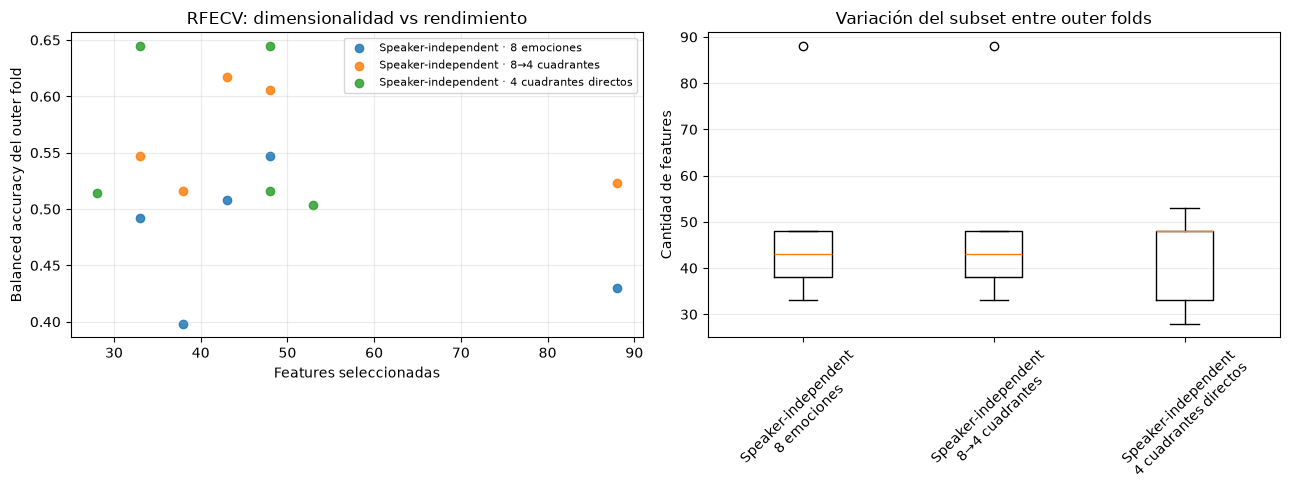

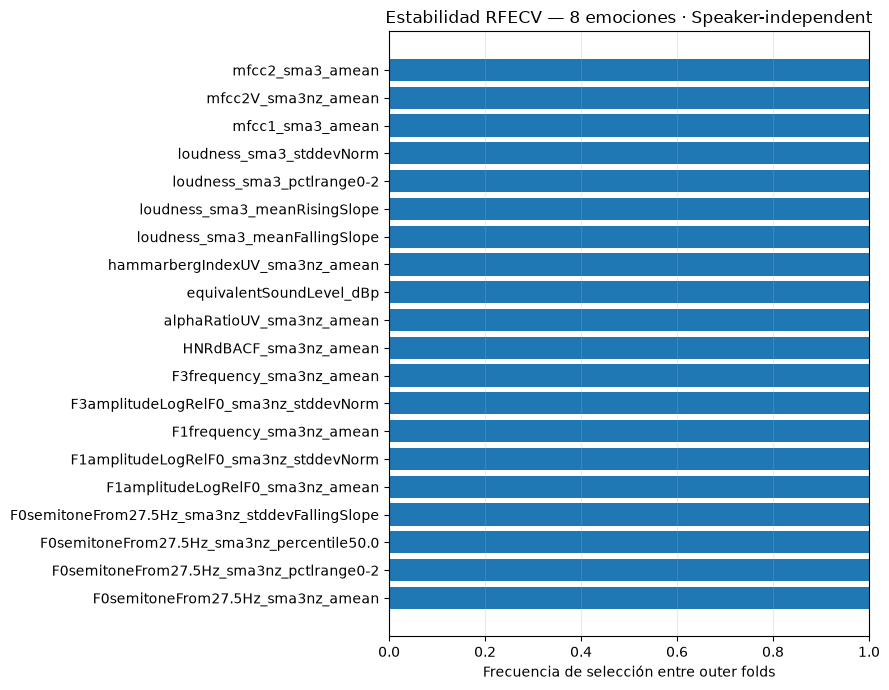

In [7]:
RFECV_STABILITY_PROTOCOL = PROTOCOLS[0]
RFECV_STABILITY_TARGET = "emotion_original"

figures = plot_rfecv_diagnostics(
    rfecv_rows,
    feature_selection,
    metric=PRIMARY_METRIC,
    stability_protocol=RFECV_STABILITY_PROTOCOL,
    stability_target=RFECV_STABILITY_TARGET,
)
if not figures:
    print("Sin resultados RFECV.")
else:
    plt.show()


### Lectura de RFECV

RFECV **no mejora** el balanced accuracy respecto del baseline con las 88 features completas — en las tres targets queda igual o levemente por debajo. La reducción de dimensionalidad no se traduce en mejor generalización en ninguno de los tres casos — el subset de features que RFECV selecciona en cada fold varía (ver boxplot), lo que sugiere que la selección es sensible a qué actores caen en cada partición y no converge a un subconjunto estable. RFECV sigue siendo útil como herramienta de interpretación (qué familias de features se seleccionan con más frecuencia), pero no como mejora de rendimiento en este proyecto.

## 6. PCA dentro de outer CV

In [8]:
if RUN_PCA:
    pca_output = run_pca_grid(
        representations=representations,
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        representation_names=REPRESENTATIONS,
        protocols=PROTOCOLS,
        targets=TARGETS,
        variance_thresholds=cfg.refinements.pca.variance_thresholds,
        n_folds=cfg.splits.cv_folds,
    )

    cv_results = upsert_cv_results(
        cv_results,
        pca_output["fold_results"],
    )
    save_cv_results(cv_results, cv_results_path)

pca_rows = (
    cv_results[
        cv_results["refinement"].astype(str).str.startswith("pca_")
    ]
    if not cv_results.empty
    else pd.DataFrame()
)

2026-07-04 15:36:07 | INFO     | src.experiments.cross_validation | === CV: egemaps_logistic_regression_emotion_original_speaker_independent_pca_90 ===
2026-07-04 15:36:08 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.4748 | BalAcc=0.4883 | UAR=0.4883 | Acc=0.4833
2026-07-04 15:36:08 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.4100 | BalAcc=0.3984 | UAR=0.3984 | Acc=0.4125
2026-07-04 15:36:08 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.4620 | BalAcc=0.4883 | UAR=0.4883 | Acc=0.4708
2026-07-04 15:36:08 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.4637 | BalAcc=0.4648 | UAR=0.4648 | Acc=0.4792
2026-07-04 15:36:08 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.4248 | BalAcc=0.4375 | UAR=0.4375 | Acc=0.4500
2026-07-04 15:36:08 | INFO     | src.experiments.cross_validation | === egemaps_logistic_regression_emotion_original_speaker_independent_pca_90 — balanced_accuracy 0.4555 ± 0.0341 ===
2026-07-04 15:36:08 | INFO     | src.ex

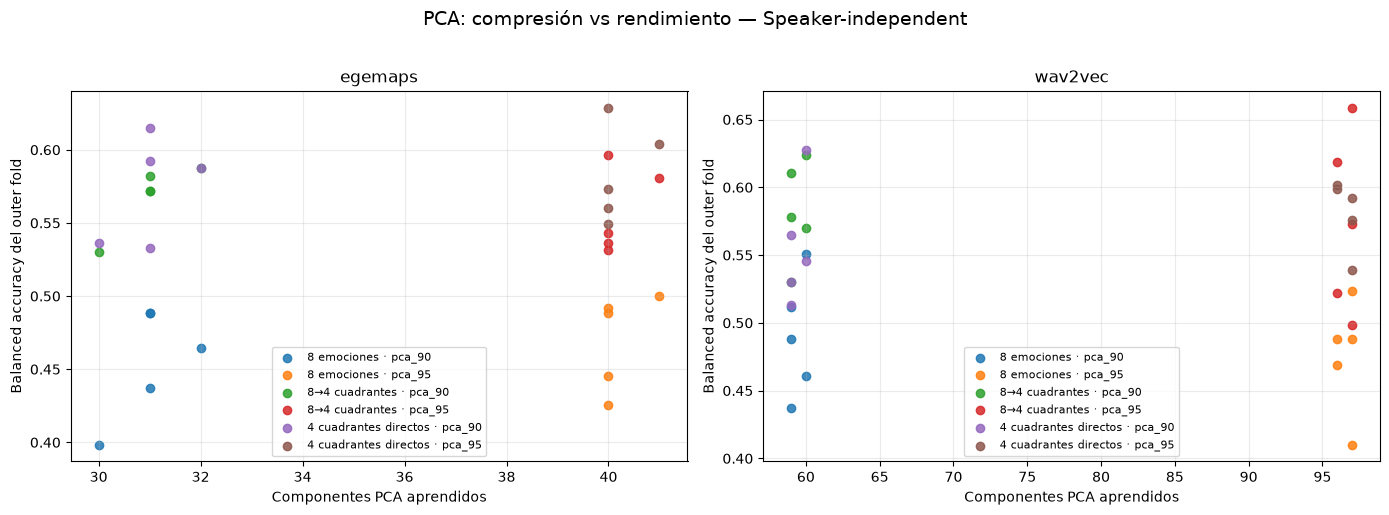

In [9]:
PCA_PROTOCOL = PROTOCOLS[0]

figure = plot_pca_diagnostics(
    pca_rows,
    representations=REPRESENTATIONS,
    protocol=PCA_PROTOCOL,
    metric=PRIMARY_METRIC,
)
if figure is None:
    print("Sin resultados PCA.")
else:
    plt.show()


### Lectura de PCA dentro de CV

PCA reduce el balanced accuracy medio en 5 de las 6 combinaciones representación×target evaluadas, comparado contra el baseline sin PCA de la misma representación y target. La única configuración que se acerca a justificar el trade-off es **eGeMAPS · emotion_quadrant · PCA 95%**: pierde apenas 0.007 de media (0.589 → 0.582) mientras reduce el desvío entre folds un 37% (0.037 → 0.024). En el resto de los casos la caída de rendimiento es demasiado grande para compensarla con la reducción de dimensionalidad — ninguna configuración con wav2vec se beneficia de PCA en esta etapa, algo consistente con perder información temporal fina al comprimir el embedding mean-pooled a tan pocos componentes.

## 7. Comparación visual baseline vs refinamientos

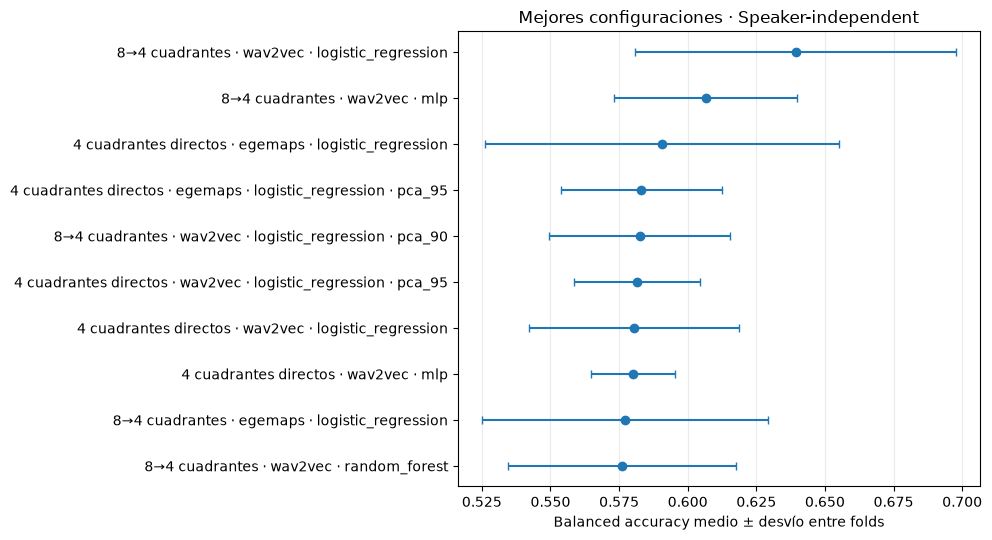

In [10]:
if not cv_results.empty:
    summary = summarize_cv_results(cv_results)
    figure = plot_ranked_configurations(
        summary,
        protocol=PROTOCOLS[0],
        metric=PRIMARY_METRIC,
        top_n=10,
    )
    if figure is not None:
        plt.show()


## 8. Matrices de confusión normalizadas

Se construyen a partir de predicciones *out-of-fold* de development:

1. una matriz para el mejor baseline de cada target;
2. una comparación controlada de Logistic Regression antes y después del mejor refinamiento compatible;
3. una matriz de diferencias `refinamiento − baseline`.

La matriz de diferencias debe leerse así:

- diagonal positiva: mejora del recall de esa clase;
- diagonal negativa: empeoramiento;
- valores fuera de diagonal: cambios en patrones de confusión.

La comparación controlada mantiene representación, modelo, target, protocolo y folds.

In [11]:
CONFUSION_PROTOCOL = PROTOCOLS[0]
REFINEMENT_TRACK_TARGET = "emotion_original"

best_baselines = pd.DataFrame()
track_configs = pd.DataFrame()
oof_predictions = pd.DataFrame()

if summary.empty:
    print("No hay resultados para seleccionar matrices de confusión.")
elif not RUN_CONFUSION_MATRICES:
    print("Matrices de confusión desactivadas.")
else:
    best_baselines = select_best_baselines(
        summary,
        protocol=CONFUSION_PROTOCOL,
        metric=PRIMARY_METRIC,
    )
    track_configs = select_controlled_refinement_tracks(
        summary,
        protocol=CONFUSION_PROTOCOL,
        target=REFINEMENT_TRACK_TARGET,
        representations=REPRESENTATIONS,
        metric=PRIMARY_METRIC,
    )
    selected_configs = combine_configurations(
        best_baselines,
        track_configs,
    )

    if selected_configs.empty:
        print("No hay configuraciones compatibles para calcular OOF.")
    else:
        collect_predictions = partial(
            collect_oof_predictions,
            representations=representations,
            metadata=metadata,
            splits=splits,
            model_configs=cfg.models,
            rfecv_config=cfg.refinements.rfecv,
            seed=cfg.seed,
            n_folds=cfg.splits.cv_folds,
        )
        oof_predictions = load_or_collect_oof(
            selected_configs,
            cache_path=oof_cache_path,
            collect_fn=collect_predictions,
        )


Calculando OOF: representation=egemaps | protocol=speaker_independent | target=emotion_quadrant | model=logistic_regression | refinement=none
2026-07-04 15:36:20 | INFO     | src.experiments.cross_validation | === CV: egemaps_logistic_regression_emotion_quadrant_speaker_independent_none ===
2026-07-04 15:36:20 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.6359 | BalAcc=0.6523 | UAR=0.6523 | Acc=0.6542
2026-07-04 15:36:20 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.5322 | BalAcc=0.5365 | UAR=0.5365 | Acc=0.5458
2026-07-04 15:36:20 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.5361 | BalAcc=0.5547 | UAR=0.5547 | Acc=0.5833
2026-07-04 15:36:20 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.6590 | BalAcc=0.6836 | UAR=0.6836 | Acc=0.6708
2026-07-04 15:36:20 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.5261 | BalAcc=0.5260 | UAR=0.5260 | Acc=0.5542
2026-07-04 15:36:20 | INFO     | src.experiments.cross_validation | === egemaps_log

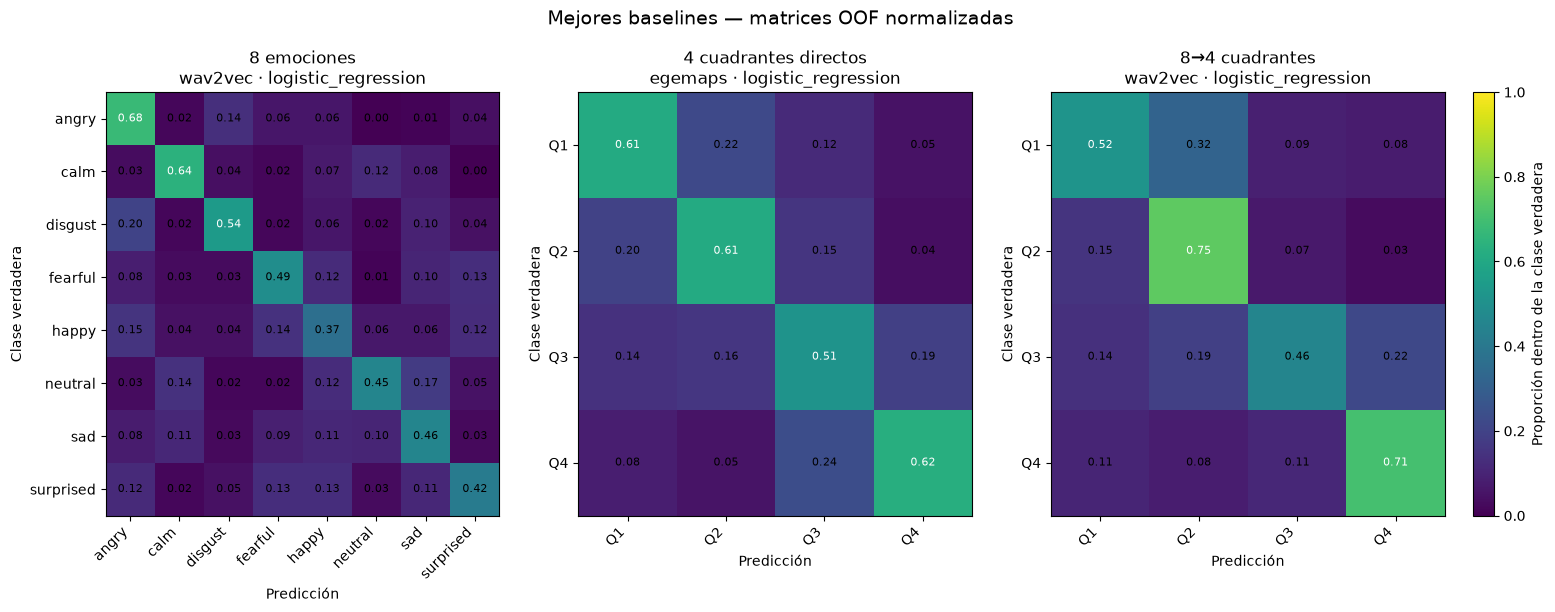

In [12]:
if RUN_CONFUSION_MATRICES:
    figure = plot_best_baseline_confusions(
        best_baselines,
        oof_predictions,
        target_order=TARGETS,
    )
    if figure is None:
        print("No hay baselines OOF para graficar.")
    else:
        plt.show()


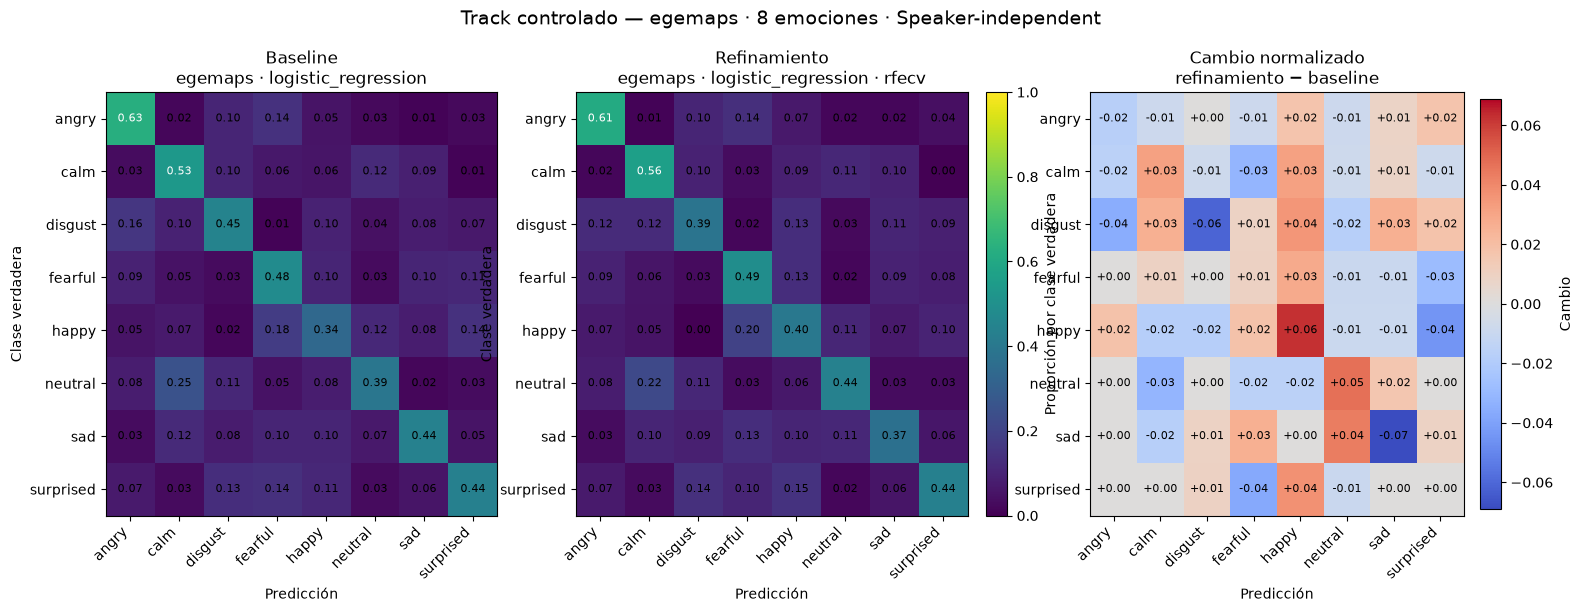

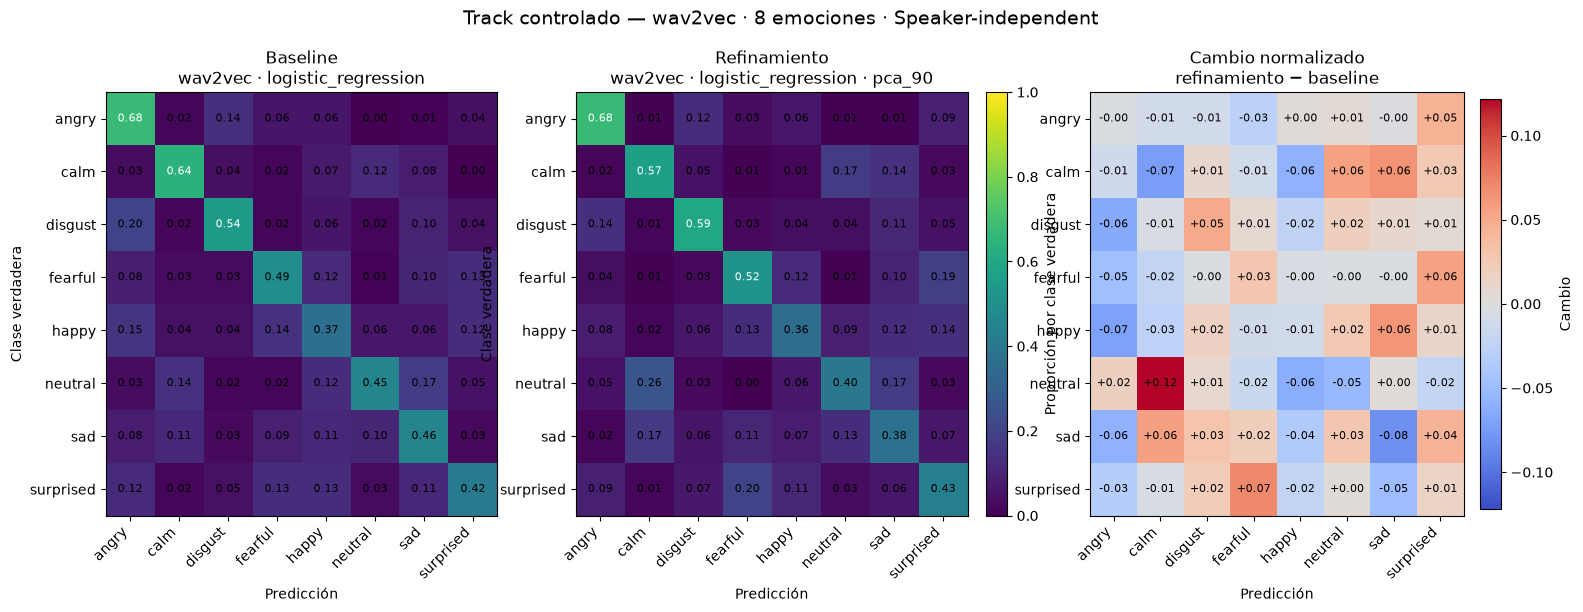

In [13]:
if RUN_CONFUSION_MATRICES:
    figures = plot_controlled_refinement_confusions(
        track_configs,
        oof_predictions,
        target=REFINEMENT_TRACK_TARGET,
        protocol=CONFUSION_PROTOCOL,
    )
    if not figures:
        print("No hay pares baseline/refinamiento comparables.")
    else:
        plt.show()


## Conclusión del notebook

### Hallazgos:

1. **Los modelos lineales le ganan a los no lineales en las seis combinaciones representación×target.** Con ~960 muestras de entrenamiento por fold, ni Random Forest ni el MLP logran superar a Logistic Regression. Este proyecto vive en un régimen de datos donde la regularización importa más que la capacidad del modelo — el mismo argumento que en `03c_temporal_pooling_layer_mixture.ipynb`.

2. **Entrenar sobre 8 clases y colapsar después supera a entrenar directamente sobre 4.** El efecto de entrenar sobre ocho emociones y colapsar posteriormente a cuadrantes depende de la representación. En wav2vec, conservar las ocho etiquetas durante el entrenamiento mejora la evaluación posterior en cuadrantes, lo que sugiere que la supervisión emocional más detallada ayuda a estructurar el embedding. En eGeMAPS, en cambio, la clasificación directa de los cuatro cuadrantes obtiene mejor rendimiento. Por lo tanto, no existe una ventaja universal de una formulación sobre la otra.

3. **Ni RFECV ni PCA mejoran el rendimiento de la representación completa.** RFECV queda igual o levemente por debajo del baseline de 88 features en las tres targets, con un subset de features que además varía fold a fold. PCA reduce el balanced accuracy en 5 de 6 combinaciones evaluadas; la única excepción parcial (eGeMAPS · `emotion_quadrant` · 95% de varianza) gana estabilidad (−37% de desvío) a costa de una pérdida de rendimiento mínima (−0.007), pero no cambia la elección del mejor modelo. En conjunto, estos dos intentos de refinamiento no encontraron una mejora real dentro de las representaciones ya extraídas. La señal motiva explorar información temporal más rica en lugar de continuar refinando representaciones estáticas.

### La comparación controlada

El resultado confirma que para `emotion_original` + Logistic Regression, el mejor refinamiento disponible queda por debajo del baseline sin refinar tanto en eGeMAPS (RFECV: 0.502 vs. 0.511, −0.009) como en wav2vec2 (PCA 95%: 0.495 vs. 0.558, −0.063). La caída es especialmente marcada en wav2vec, reforzando que comprimir ese embedding con PCA no es un buen camino para este proyecto.

> ### Detalle importante
> ---
> El early stopping interno de `MLPClassifier` utiliza una partición aleatoria del outer train y no una separación adicional por actor. Esto no introduce información del outer validation ni del test, por lo que las métricas speaker-independent permanecen válidas. Sin embargo, la selección interna de la época puede beneficiarse parcialmente de observar los mismos hablantes en entrenamiento y validación interna, y constituye una limitación específica del baseline MLP.

> Los hiperparámetros de los clasificadores baseline se fijaron con valores conservadores y se mantuvieron constantes para priorizar una comparación controlada entre representaciones. La selección experimental se concentró en el tipo de representación, el refinamiento y el pooling, y no en una optimización exhaustiva de cada clasificador. Ningún hiperparámetro fue modificado después de observar el test final.
